In [10]:

!pip install fastf1
!pip install torch
!pip install scikit-learn


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 10.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.4/308.4 kB 12.1 MB/s eta 0:00:00
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [11]:
import fastf1
from fastf1 import plotting
from fastf1.core import Laps
import matplotlib.pyplot as plt


from typing import Iterable, List, Optional
import warnings
import pandas as pd
import numpy as np
import requests
import json
from scipy.signal import find_peaks
import io
import os
import math, numpy as np
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

In [12]:
# =========================
# CONFIG
# =========================
YEAR                  = 2024
EVENT_NAME            = "Bahrain"
SESSION_FP            = "FP3"                        # "FP1"/"FP2"/"FP3"
SESSION_Q             = "Q"                          # kept for completeness (target lookup)
TELEMETRY_CHANNELS    = ["Speed", "Throttle"]        # add "Brake","nGear","DRS","RPM" later
CHANNELS              = TELEMETRY_CHANNELS + ["Distance", "Curvature"]
N_SAMPLES             = 2048                         # sequence length (distance-aligned)
CACHE_DIR             = "./f1cache"                  # fastf1 cache

In [13]:
def print_all_races(years=range(2018, 2025)):
    """
    Print all races for each year in `years` using FastF1's event schedule.

    Output format (one per race):
      YEAR | RND | EventName | Country | Location
    """
    for year in years:
        print(f"\n========== {year} ==========")
        try:
            schedule = fastf1.get_event_schedule(year)
        except Exception as e:
            print(f"Could not load schedule for {year}: {e}")
            continue

        # Some FastF1 versions use 'RoundNumber', but be robust:
        round_col_candidates = ["RoundNumber", "EventFormat", "SessionFormat"]
        if "RoundNumber" in schedule.columns:
            round_col = "RoundNumber"
        else:
            # Fallback: just use the index+1 as round
            round_col = None

        for i, row in schedule.iterrows():
            if round_col is not None:
                rnd = int(row.get(round_col, i + 1))
            else:
                rnd = i + 1

            event_name = str(row.get("EventName", "")).strip()
            country    = str(row.get("Country", "")).strip()
            location   = str(row.get("Location", "")).strip()

            print(f"{year} | {rnd:2d} | {event_name} | {country} | {location}")


In [14]:
print_all_races(range(2018, 2025))

req         WARNING 	DEFAULT CACHE ENABLED! (330.33 MB) /Users/leoqian/Library/Caches/fastf1



========== 2018 ==========
2018 |  1 | Australian Grand Prix | Australia | Melbourne
2018 |  2 | Bahrain Grand Prix | Bahrain | Sakhir
2018 |  3 | Chinese Grand Prix | China | Shanghai
2018 |  4 | Azerbaijan Grand Prix | Azerbaijan | Baku
2018 |  5 | Spanish Grand Prix | Spain | Barcelona
2018 |  6 | Monaco Grand Prix | Monaco | Monte Carlo
2018 |  7 | Canadian Grand Prix | Canada | Montréal
2018 |  8 | French Grand Prix | France | Le Castellet
2018 |  9 | Austrian Grand Prix | Austria | Spielberg
2018 | 10 | British Grand Prix | Great Britain | Silverstone
2018 | 11 | German Grand Prix | Germany | Hockenheim
2018 | 12 | Hungarian Grand Prix | Hungary | Budapest
2018 | 13 | Belgian Grand Prix | Belgium | Spa-Francorchamps
2018 | 14 | Italian Grand Prix | Italy | Monza
2018 | 15 | Singapore Grand Prix | Singapore | Singapore
2018 | 16 | Russian Grand Prix | Russia | Sochi
2018 | 17 | Japanese Grand Prix | Japan | Suzuka
2018 | 18 | United States Grand Prix | United States | Austin
2018

In [15]:
"""
Track Mapping for Circuit IDs to FastF1 Event Names

Maps circuit_id values from HOLY_qualifying_v1.csv to:
1. FastF1 event names (for telemetry collection)
2. TUM FTM Raceline URLs (for track geometry)

Note: Some circuits may not have raceline data or FastF1 data available.
"""

# Mapping from circuit_id to FastF1 event name
# FastF1 event names are case-insensitive but we use official capitalization
CIRCUIT_TO_FASTF1 = {
    # Modern F1 circuits (2018+)
    'bahrain': 'Bahrain',
    'sakhir': 'Sakhir',  # Also Bahrain (outer circuit used in 2020)
    'jeddah': 'Jeddah',
    'albert_park': 'Australia',
    'melbourne': 'Australia',
    'imola': 'Emilia Romagna',
    'miami': 'Miami',
    'monaco': 'Monaco',
    'barcelona': 'Spain',
    'catalunya': 'Spain',
    'montreal': 'Canada',
    'montréal': 'Canada',
    'villeneuve': 'Canada',
    'red_bull_ring': 'Austria',
    'spielberg': 'Austria',
    'silverstone': 'Great Britain',
    'hungaroring': 'Hungary',
    'budapest': 'Hungary',
    'spa': 'Belgium',
    'spa_francorchamps': 'Belgium',
    'zandvoort': 'Netherlands',
    'monza': 'Italy',
    'marina_bay': 'Singapore',
    'suzuka': 'Japan',
    'losail': 'Qatar',
    'lusail': 'Qatar',  # Alternative spelling used in dataset
    'austin': 'United States',
    'americas': 'United States',
    'mexico_city': 'Mexico',
    'rodriguez': 'Mexico',
    'interlagos': 'Brazil',
    'são_paulo': 'São Paulo',
    'las_vegas': 'Las Vegas',
    'yas_marina': 'Abu Dhabi',
    'baku': 'Azerbaijan',
    'shanghai': 'China',
    'portimao': 'Portugal',
    'istanbul': 'Turkey',
    'mugello': 'Tuscany',
    'sochi': 'Russia',

    # Historic circuits (limited/no FastF1 data)
    'hockenheimring': 'Germany',
    'nurburgring': 'Nurburgring',
    'ricard': 'France',
    'magny_cours': 'France',
    'sepang': 'Malaysia',
    'yeongam': 'Korea',
    'buddh': 'India',
    'valencia': 'Europe',

    # Very old circuits (pre-2000, likely no FastF1 data)
    'adelaide': None,
    'brands_hatch': None,
    'dallas': None,
    'detroit': None,
    'dijon': None,
    'donington': None,
    'estoril': None,
    'fuji': None,
    'galvez': None,
    'indianapolis': None,
    'jacarepagua': None,
    'jerez': None,
    'kyalami': None,
    'long_beach': None,
    'okayama': None,
    'phoenix': None,
    'zolder': None,
}

# Mapping from circuit_id to  eoJSON URL
# Source: https://github.com/bacinger/f1-circuits
CIRCUIT_TO_RACELINE_URL = {
    # Modern F1 circuits (active)
    'bahrain': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/bh-2002.geojson',
    'sakhir': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/bh-2002.geojson',
    'jeddah': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/sa-2021.geojson',
    'melbourne': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/au-1953.geojson',
    'albert_park': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/au-1953.geojson',
    'baku': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/az-2016.geojson',
    'miami': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/us-2022.geojson',
    'monaco': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/mc-1929.geojson',
    'barcelona': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/es-1991.geojson',
    'catalunya': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/es-1991.geojson',
    'montreal': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/ca-1978.geojson',
    'montréal': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/ca-1978.geojson',
    'villeneuve': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/ca-1978.geojson',
    'spielberg': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/at-1969.geojson',
    'red_bull_ring': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/at-1969.geojson',
    'silverstone': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/gb-1948.geojson',
    'hungaroring': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/hu-1986.geojson',
    'budapest': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/hu-1986.geojson',
    'spa': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/be-1925.geojson',
    'spa_francorchamps': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/be-1925.geojson',
    'zandvoort': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/nl-1948.geojson',
    'monza': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/it-1922.geojson',
    'marina_bay': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/sg-2008.geojson',
    'suzuka': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/jp-1962.geojson',
    'losail': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/qa-2004.geojson',
    'lusail': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/qa-2004.geojson',
    'austin': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/us-2012.geojson',
    'americas': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/us-2012.geojson',
    'mexico_city': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/mx-1962.geojson',
    'rodriguez': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/mx-1962.geojson',
    'interlagos': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/br-1940.geojson',
    'são_paulo': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/br-1940.geojson',
    'las_vegas': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/us-2023.geojson',
    'yas_marina': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/ae-2009.geojson',

    # Recently retired circuits
    'portimao': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/pt-2008.geojson',
    'istanbul': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/tr-2005.geojson',
    'sochi': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/ru-2014.geojson',
    'nurburgring': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/de-1927.geojson',
    'hockenheimring': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/de-1932.geojson',
    'sepang': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/my-1999.geojson',
    'shanghai': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/cn-2004.geojson',

    # Historic circuits
    'imola': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/it-1953.geojson',
    'mugello': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/it-1914.geojson',
    'ricard': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/fr-1969.geojson',
    'magny_cours': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/fr-1960.geojson',
    'estoril': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/pt-1972.geojson',
    'jacarepagua': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/br-1977.geojson',
    'kyalami': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/za-1961.geojson',
    'indianapolis': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/us-1909.geojson',
    'galvez': 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/ar-1952.geojson',

    # Circuits not in bacinger repository
    'brands_hatch': None,
    'yeongam': None,
    'buddh': None,
    'valencia': None,
    'adelaide': None,
    'dallas': None,
    'detroit': None,
    'dijon': None,
    'donington': None,
    'fuji': None,
    'jerez': None,
    'long_beach': None,
    'okayama': None,
    'phoenix': None,
    'zolder': None,
}


def get_fastf1_event_name(circuit_id: str) -> str:
    """
    Get FastF1 event name for a circuit_id.

    Args:
        circuit_id: Circuit identifier from dataset (e.g., 'monaco', 'bahrain')

    Returns:
        FastF1 event name (e.g., 'Monaco', 'Bahrain') or None if not available
    """
    return CIRCUIT_TO_FASTF1.get(circuit_id.lower())


def get_raceline_url(circuit_id: str) -> str:
    """
    Get bacinger GeoJSON raceline URL for a circuit_id.

    Args:
        circuit_id: Circuit identifier from dataset (e.g., 'monaco', 'bahrain')

    Returns:
        URL to raceline GeoJSON or None if not available
    """
    return CIRCUIT_TO_RACELINE_URL.get(circuit_id.lower())


def has_raceline(circuit_id: str) -> bool:
    """Check if circuit has raceline data available."""
    return get_raceline_url(circuit_id) is not None


def has_fastf1_data(circuit_id: str) -> bool:
    """Check if circuit has FastF1 event mapping."""
    return get_fastf1_event_name(circuit_id) is not None


def get_circuits_with_racelines():
    """Get list of all circuits that have raceline data."""
    return [cid for cid, url in CIRCUIT_TO_RACELINE_URL.items() if url is not None]


def get_circuits_with_fastf1():
    """Get list of all circuits that have FastF1 event mappings."""
    return [cid for cid, name in CIRCUIT_TO_FASTF1.items() if name is not None]


if __name__ == '__main__':
    """Test the mappings"""
    print("=== Track Mapping Test ===\n")

    test_circuits = ['monaco', 'bahrain', 'silverstone', 'adelaide', 'miami']

    for circuit in test_circuits:
        fastf1_name = get_fastf1_event_name(circuit)
        raceline_url = get_raceline_url(circuit)

        print(f"Circuit: {circuit}")
        print(f"  FastF1: {fastf1_name if fastf1_name else 'NOT AVAILABLE'}")
        print(f"  Raceline: {'AVAILABLE' if raceline_url else 'NOT AVAILABLE'}")
        print()

    print(f"\nTotal circuits with racelines: {len(get_circuits_with_racelines())}")
    print(f"Total circuits with FastF1 data: {len(get_circuits_with_fastf1())}")

=== Track Mapping Test ===

Circuit: monaco
  FastF1: Monaco
  Raceline: AVAILABLE

Circuit: bahrain
  FastF1: Bahrain
  Raceline: AVAILABLE

Circuit: silverstone
  FastF1: Great Britain
  Raceline: AVAILABLE

Circuit: adelaide
  FastF1: NOT AVAILABLE
  Raceline: NOT AVAILABLE

Circuit: miami
  FastF1: Miami
  Raceline: AVAILABLE


Total circuits with racelines: 50
Total circuits with FastF1 data: 48


In [16]:
def load_raceline_geojson(raw_url: str) -> pd.DataFrame:
    """
    Load raceline GeoJSON and return float columns x_m, y_m.
    Extracts coordinates from GeoJSON LineString geometry.
    """
    r = requests.get(raw_url, timeout=30)
    r.raise_for_status()

    geojson_data = json.loads(r.text)

    # Extract coordinates from GeoJSON structure
    # GeoJSON can be FeatureCollection or single Feature
    if geojson_data.get('type') == 'FeatureCollection':
        features = geojson_data.get('features', [])
        if not features:
            raise ValueError("No features found in GeoJSON")
        # Take first feature (usually the track)
        geometry = features[0].get('geometry', {})
    elif geojson_data.get('type') == 'Feature':
        geometry = geojson_data.get('geometry', {})
    else:
        # Might be just geometry
        geometry = geojson_data

    # Extract coordinates from LineString or MultiLineString
    coords = []
    if geometry.get('type') == 'LineString':
        coords = geometry.get('coordinates', [])
    elif geometry.get('type') == 'MultiLineString':
        # Flatten all line segments
        for line in geometry.get('coordinates', []):
            coords.extend(line)
    else:
        raise ValueError(f"Unsupported geometry type: {geometry.get('type')}")

    if not coords:
        raise ValueError("No coordinates found in GeoJSON")

    # Convert to DataFrame
    # GeoJSON coordinates are [lon, lat]
    df = pd.DataFrame(coords, columns=['lon', 'lat'])

    # If coordinates look like lat/lon (small values), convert to meters using Web Mercator-like projection
    # This is a heuristic: if values are between -180 and 180, assume lat/lon
    if df['lon'].abs().max() < 200 and df['lat'].abs().max() < 200:
        # Use a local tangent plane projection centered on the track
        # This is more accurate than simple degree multiplication
        center_lon = df['lon'].mean()
        center_lat = df['lat'].mean()

        # Convert to radians
        lon_rad = np.radians(df['lon'].values)
        lat_rad = np.radians(df['lat'].values)
        center_lon_rad = np.radians(center_lon)
        center_lat_rad = np.radians(center_lat)

        # Earth radius in meters
        R = 6371000

        # Project to local Cartesian coordinates (meters)
        # x = R * cos(center_lat) * (lon - center_lon)
        # y = R * (lat - center_lat)
        df['x_m'] = R * np.cos(center_lat_rad) * (lon_rad - center_lon_rad)
        df['y_m'] = R * (lat_rad - center_lat_rad)
    else:
        # Already in meters or other Cartesian system
        df['x_m'] = df['lon']
        df['y_m'] = df['lat']

    # Keep only x_m and y_m columns
    df = df[['x_m', 'y_m']].copy()
    df = df.dropna(subset=["x_m", "y_m"]).reset_index(drop=True)

    if (df.iloc[0] != df.iloc[-1]).any():
        df = pd.concat([df, df.iloc[[0]]], ignore_index=True)

    return df

def arc_length(df: pd.DataFrame) -> pd.Series:
    dx = np.diff(df.x_m, prepend=df.x_m.iloc[0])
    dy = np.diff(df.y_m, prepend=df.y_m.iloc[0])
    return pd.Series(np.cumsum(np.hypot(dx, dy)), name="s_m")

def curvature_from_xy(x: np.ndarray, y: np.ndarray, s: np.ndarray) -> np.ndarray:
    # central differences on arc-length parameter s
    # guard against non-strictly-increasing s
    s = np.maximum.accumulate(s + 1e-12*np.arange(len(s)))
    x_s  = np.gradient(x, s)
    y_s  = np.gradient(y, s)
    x_ss = np.gradient(x_s, s)
    y_ss = np.gradient(y_s, s)
    kappa = np.abs(x_s * y_ss - y_s * x_ss) / np.power(x_s**2 + y_s**2, 1.5)
    # numerical safety
    kappa = np.nan_to_num(kappa, nan=0.0, posinf=0.0, neginf=0.0)
    return kappa

def resample_equal_arclength(df: pd.DataFrame, step_m: float = 2.0) -> pd.DataFrame:
    """Resample polyline to ~constant spacing along s, improving curvature stability."""
    s = arc_length(df).values
    s_new = np.arange(0, s[-1], step_m)
    # linear interpolation
    x_new = np.interp(s_new, s, df.x_m.values)
    y_new = np.interp(s_new, s, df.y_m.values)
    out = pd.DataFrame({"s_m": s_new, "x_m": x_new, "y_m": y_new})
    # close loop exactly
    if (out.iloc[0][["x_m","y_m"]].values != out.iloc[-1][["x_m","y_m"]].values).any():
        out = pd.concat([out, out.iloc[[0]]], ignore_index=True)
        out.loc[out.index[-1], "s_m"] = out["s_m"].iloc[-2] + step_m
    return out

def load_track_raceline(circuit_id: str, step_m: float = 2.0):
    """
    Full pipeline:
    1. Look up track URL from CIRCUIT_TO_RACELINE_URL
    2. Load GeoJSON raceline
    3. Resample to equal arc length
    4. Compute curvature
    5. Return raceline df + start point
    """
    url = get_raceline_url(circuit_id)
    if url is None:
        raise ValueError(f"No raceline available for circuit '{circuit_id}'")

    # Load xy from GeoJSON
    df = load_raceline_geojson(url)

    # Resample (constant spacing)
    rl_eq = resample_equal_arclength(df, step_m=step_m)

    # Curvature
    kappa = curvature_from_xy(
        rl_eq.x_m.values,
        rl_eq.y_m.values,
        rl_eq.s_m.values
    )
    rl_eq["kappa"] = kappa

    # Start point = s_m == 0 row
    start_point = rl_eq.iloc[0]

    return rl_eq, start_point

Start-of-polyline point (s_m = 0):
s_m      0.000000
x_m   -357.714119
y_m    -50.592509
Name: 0, dtype: float64
         s_m         x_m        y_m         kappa
0        0.0 -357.714119 -50.592509  7.277147e-15
1        2.0 -357.658408 -48.593285  3.626203e-15
2        4.0 -357.602696 -46.594061  0.000000e+00
3        6.0 -357.546985 -44.594837  1.237042e-17
4        8.0 -357.491274 -42.595613  3.563705e-15
...      ...         ...        ...           ...
2706  5412.0 -358.150377 -57.007851  6.025902e-17
2707  5414.0 -358.014686 -55.012459  3.886707e-15
2708  5416.0 -357.878995 -53.017068  7.962381e-16
2709  5418.0 -357.743304 -51.021676  2.124257e-14
2710  5420.0 -357.714119 -50.592509  3.485362e-13

[2711 rows x 4 columns]
=== Start Point ===
s_m      0.000000
x_m   -357.714119
y_m    -50.592509
Name: 0, dtype: float64

=== Raceline (first 10 rows, no x/y) ===
    s_m         kappa
0   0.0  7.277147e-15
1   2.0  3.626203e-15
2   4.0  0.000000e+00
3   6.0  1.237042e-17
4   8.0  3.5

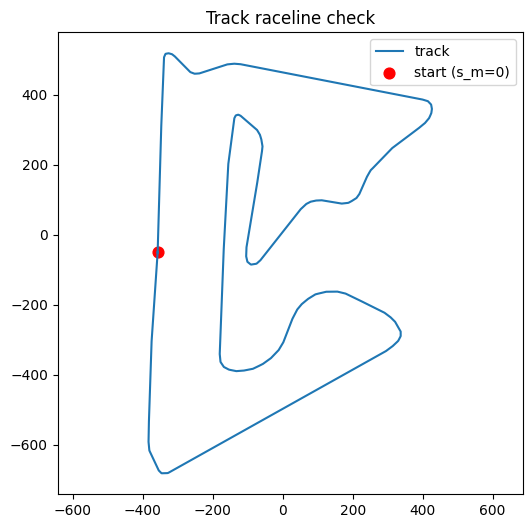

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- build raceline from GEOJSON instead of CSV ---
RAW_URL = 'https://raw.githubusercontent.com/bacinger/f1-circuits/refs/heads/master/circuits/bh-2002.geojson'

raceline = load_raceline_geojson(RAW_URL)   # uses your function (x_m, y_m)
rl_eq = resample_equal_arclength(raceline, 2.0)

# compute curvature (optional, but you already do this)
kappa = curvature_from_xy(rl_eq.x_m.values, rl_eq.y_m.values, rl_eq.s_m.values)
rl_eq["kappa"] = kappa

# --- point where s_m = 0 (start of polyline) ---
start_point = rl_eq.iloc[0]  # this row has s_m == 0
print("Start-of-polyline point (s_m = 0):")
print(start_point[["s_m", "x_m", "y_m"]])

print(rl_eq)

def print_without_xy(df: pd.DataFrame):
    cols = [c for c in df.columns if c not in ("x_m", "y_m")]
    print(df[cols])

# --- TEST 1: Load a raceline and print start point ---
rl_eq, start = load_track_raceline("bahrain")

print("=== Start Point ===")
print(start[["s_m", "x_m", "y_m"]])
print()

# --- TEST 2: Check first 10 rows WITHOUT x_m and y_m ---
print("=== Raceline (first 10 rows, no x/y) ===")
print_without_xy(rl_eq.head(10))
print()

# --- TEST 3: Sanity check for curvature values ---
print("=== Curvature stats ===")
print(rl_eq["kappa"].describe())
print()

# --- TEST 4: Plot (optional but recommended) ---
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.plot(rl_eq.x_m, rl_eq.y_m, label="track")
plt.scatter(start.x_m, start.y_m, color="red", s=60, label="start (s_m=0)")
plt.axis("equal")
plt.title("Track raceline check")
plt.legend()
plt.show()



In [18]:
def build_fastf1_to_rl_eq(step_m: float = 2.0) -> dict[str, pd.DataFrame]:
    """
    Build a dict mapping FastF1 event names -> rl_eq DataFrames.

    For each circuit_id that:
      1) has a bacinger GeoJSON raceline URL, and
      2) has a FastF1 event mapping,

    we load the raceline, resample it, compute curvature, and store the
    resulting rl_eq DataFrame under the FastF1 event name key.

    If multiple circuit_ids map to the same FastF1 event name
    (e.g. 'melbourne' and 'albert_park' -> 'Australia'), the first one
    encountered wins and later ones are skipped.
    """
    fastf1_to_rl = {}

    for circuit_id, url in CIRCUIT_TO_RACELINE_URL.items():
        if url is None:
            continue  # no raceline for this circuit

        event_name = get_fastf1_event_name(circuit_id)
        if event_name is None:
            # raceline exists but we don't have a FastF1 mapping (historic, etc.)
            continue

        # Avoid reloading the same track if multiple circuit_ids map to
        # the same FastF1 event (e.g., 'melbourne'/'albert_park' -> 'Australia')
        if event_name in fastf1_to_rl:
            continue

        rl_eq, _ = load_track_raceline(circuit_id, step_m=step_m)
        fastf1_to_rl[event_name] = rl_eq

    return fastf1_to_rl

In [19]:
fastf1_tracks = build_fastf1_to_rl_eq(step_m=2.0)

print(fastf1_tracks.keys())   # e.g. dict_keys(['Bahrain', 'Monaco', 'Spain', ...])

bahrain_rl = fastf1_tracks["Bahrain"]
print(bahrain_rl.head())

dict_keys(['Bahrain', 'Sakhir', 'Jeddah', 'Australia', 'Azerbaijan', 'Miami', 'Monaco', 'Spain', 'Canada', 'Austria', 'Great Britain', 'Hungary', 'Belgium', 'Netherlands', 'Italy', 'Singapore', 'Japan', 'Qatar', 'United States', 'Mexico', 'Brazil', 'São Paulo', 'Las Vegas', 'Abu Dhabi', 'Portugal', 'Turkey', 'Russia', 'Nurburgring', 'Germany', 'Malaysia', 'China', 'Emilia Romagna', 'Tuscany', 'France'])
   s_m         x_m        y_m         kappa
0  0.0 -357.714119 -50.592509  7.277147e-15
1  2.0 -357.658408 -48.593285  3.626203e-15
2  4.0 -357.602696 -46.594061  0.000000e+00
3  6.0 -357.546985 -44.594837  1.237042e-17
4  8.0 -357.491274 -42.595613  3.563705e-15


In [20]:
def raceline_to_telemetry(rl_eq: pd.DataFrame) -> pd.DataFrame:
    """
    Convert a raceline DataFrame (from GEOJSON) into a
    FastF1-like telemetry DataFrame with columns:
      Distance, X, Y
    """
    tel = pd.DataFrame({
        "Distance": rl_eq["s_m"].to_numpy(),
        "X": rl_eq["x_m"].to_numpy(),
        "Y": rl_eq["y_m"].to_numpy(),
    })
    # If you ever have Speed on the raceline, you can add it here too.
    return tel
